Checking GPU

In [1]:
!nvidia-smi

Mon Apr 13 06:21:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Installing dependicies

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.3 MB/s eta 0:00:00


In [2]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 42.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


Loading dataset with roboflow

In [3]:
from google.colab import userdata
api_key = userdata.get('ROBOFLOW_API_KEY')

In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key=api_key)
project = rf.workspace("rice-dataset-evccc").project("rice-plant-disease-detection-ibpov")
version = project.version(5)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Rice-plant-disease-detection-5 in yolov8:: 100%|██████████| 14840/14840 [00:07<00:00, 1913.69it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Verifying loaded dataset dir

In [15]:
import os

base_dir = "/content/Rice-plant-disease-detection-5"
sub_folders = ['train/images', 'train/labels', 'valid/images', 'valid/labels']

for folder in sub_folders:
    full_path = os.path.join(base_dir, folder)
    print(f"{full_path}: {os.path.exists(full_path)}")


/content/Rice-plant-disease-detection-5/train/images: True
/content/Rice-plant-disease-detection-5/train/labels: True
/content/Rice-plant-disease-detection-5/valid/images: True
/content/Rice-plant-disease-detection-5/valid/labels: True


In [18]:
!ls /content/Rice-plant-disease-detection-5/train/images /content/Rice-plant-disease-detection-5/valid/images

Streaming output truncated to the last 5000 lines.
bacterial_leaf_blight-2-_JPG.rf.6a33d4889d4956fa8f9d66f7a13a9c6a.jpg
bacterial_leaf_blight-2-_JPG.rf.8b99d20c63271f245bbf62672873840f.jpg
bacterial_leaf_blight-302-_jpg.rf.781a7948fe3f110c13dd091995fe97fb.jpg
bacterial_leaf_blight-302-_jpg.rf.a3d6dd073e10b44ab034e0f33a78466e.jpg
bacterial_leaf_blight-302-_jpg.rf.e76827899ce8d2c3ebc5d8ce0f7afe56.jpg
bacterial_leaf_blight-303-_jpg.rf.0cb31132929c406aa5a7fa054f31557c.jpg
bacterial_leaf_blight-303-_jpg.rf.39ebb39b5e63fffaae03e814f4807232.jpg
bacterial_leaf_blight-303-_jpg.rf.48265ce93daf79658cfb2994b0661171.jpg
bacterial_leaf_blight-304-_jpg.rf.630bb10e687f5e869da37d8a43b30174.jpg
bacterial_leaf_blight-304-_jpg.rf.b462a403b7cea0ddecb839e67382ae81.jpg
bacterial_leaf_blight-304-_jpg.rf.c235ff9ece00cb37a7ce03b58d178076.jpg
bacterial_leaf_blight-305-_JPG.rf.051f0f8b0ed5bb7b640e3667949e217f.jpg
bacterial_leaf_blight-305-_JPG.rf.3b289e71ff1342a4daa9733625a00b7c.jpg
bacterial_leaf_blight-305-_JPG

Verify num of images on each dataset

In [22]:
print(f"Train images: {len(os.listdir(base_dir + '/train/images'))}")
print(f"Val images: {len(os.listdir(base_dir + '/valid/images'))}")


Train images: 6762
Val images: 484


Checking the label file

In [25]:
label_file = os.path.join(base_dir + '/train/labels', os.listdir(base_dir + '/train/labels')[0])
with open(label_file, 'r') as f:
    print(f"Sample line: {f.readline().strip()}")


Sample line: 0 0.51875 0.5109375 0.04375 0.02890625


In [27]:
import torch
print(f"Using: {torch.cuda.get_device_name(0)}")

Using: Tesla T4


In [28]:
!yolo task=detect mode=train \
  model=yolov8n.pt \
  data=/content/Rice-plant-disease-detection-5/data.yaml \
  epochs=10 \
  imgsz=640 \
  batch=32 \
  device=0

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rice-plant-disease-detection-5/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

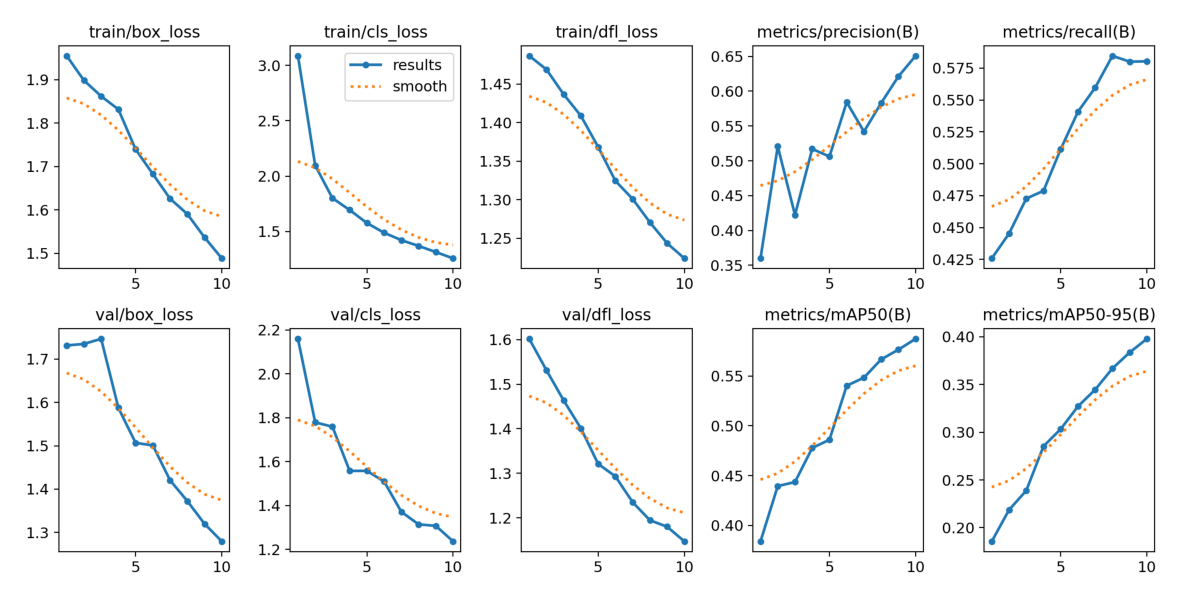

In [29]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define the path to your results
path = 'runs/detect/train/results.png'

# Load and display
img = mpimg.imread(path)
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.axis('off')  # Hide the pixel coordinates
plt.show()

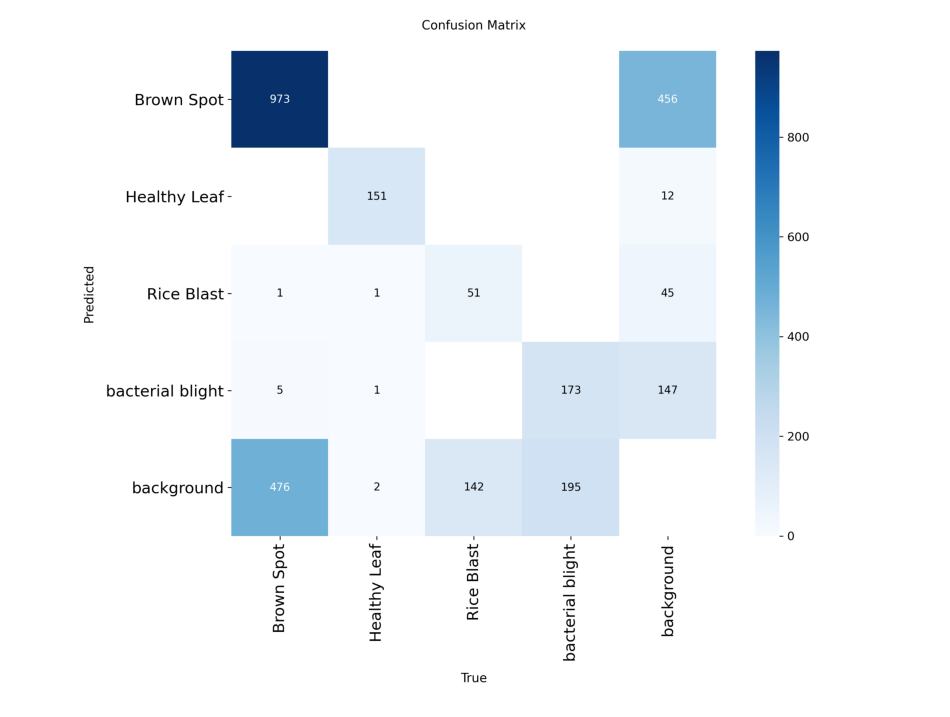

In [30]:
# You can reuse the same logic, just change the path
plt.figure(figsize=(12, 12))
img = mpimg.imread('runs/detect/train/confusion_matrix.png')
plt.imshow(img)
plt.axis('off')
plt.show()

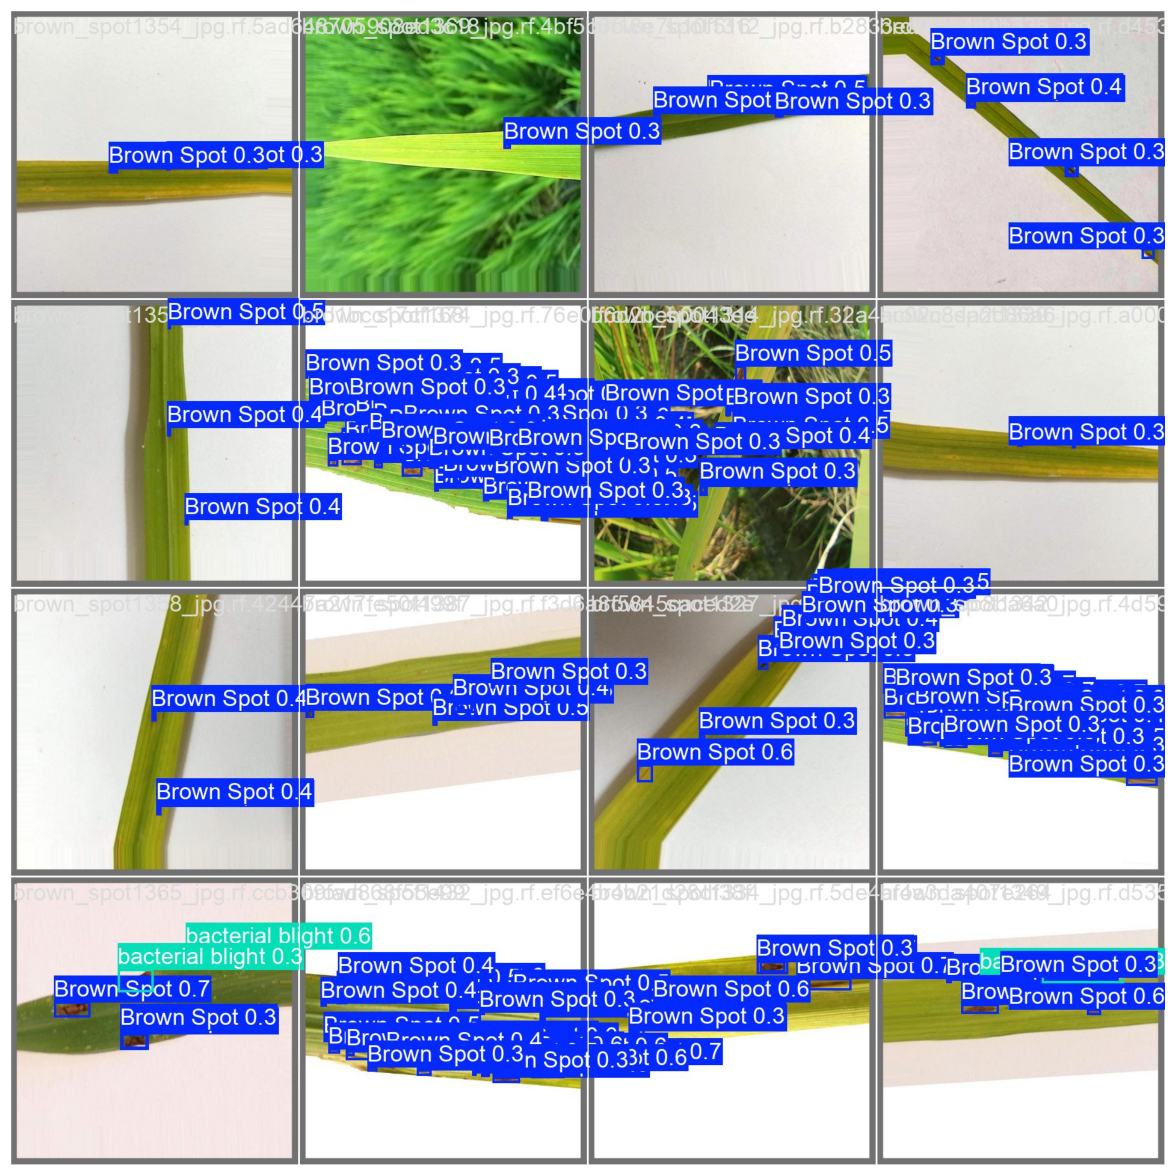

In [31]:
# Displaying the first batch of predictions
plt.figure(figsize=(15, 15))
img = mpimg.imread('runs/detect/train/val_batch0_pred.jpg')
plt.imshow(img)
plt.axis('off')
plt.show()

In [32]:
!yolo task=detect mode=train \
  model=yolov8n.pt \
  data=/content/Rice-plant-disease-detection-5/data.yaml \
  epochs=50 \
  imgsz=640 \
  batch=16 \
  device=0 \
  cls=2.0 \
  patience=15 \
  plots=True

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rice-plant-disease-detection-5/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

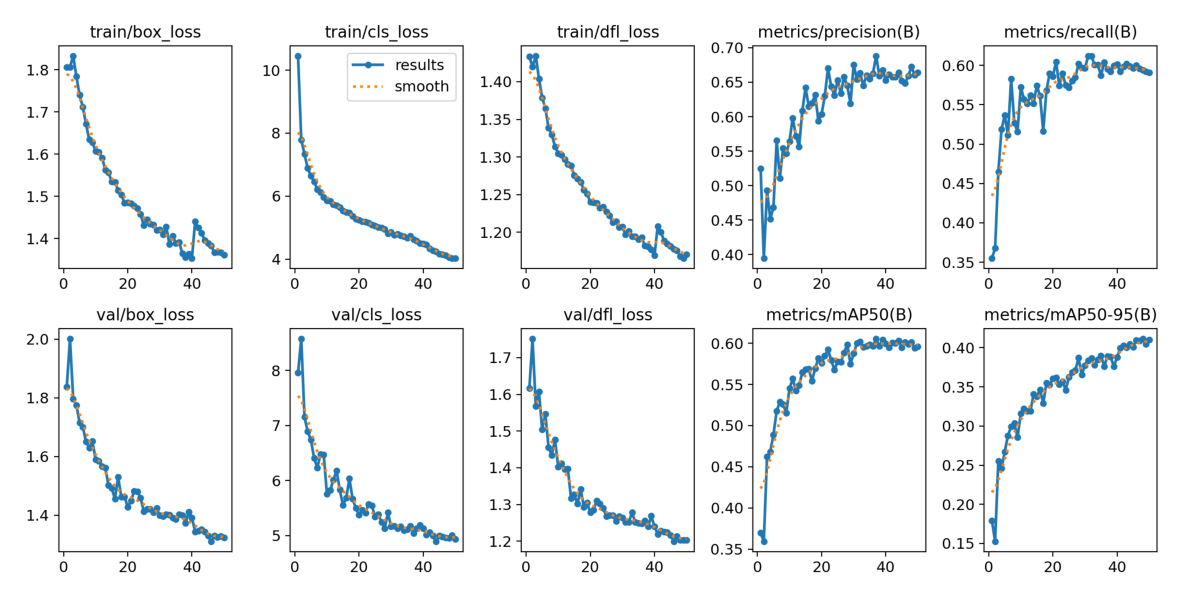

In [36]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define the path to your results
path = 'runs/detect/train2/results.png'

# Load and display
img = mpimg.imread(path)
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.axis('off')  # Hide the pixel coordinates
plt.show()

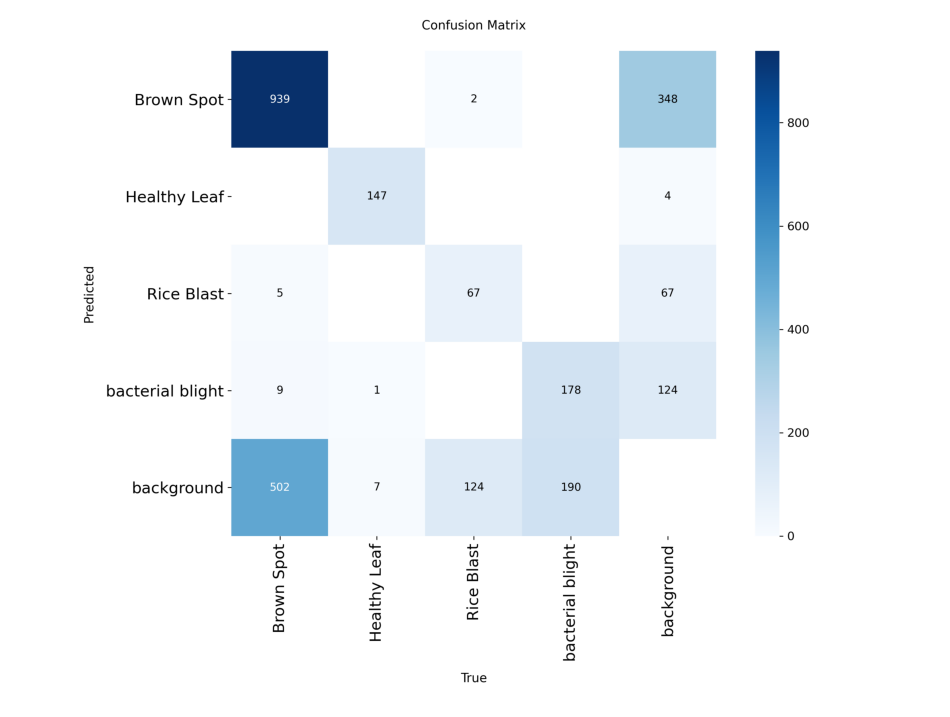

In [37]:
# You can reuse the same logic, just change the path
plt.figure(figsize=(12, 12))
img = mpimg.imread('runs/detect/train2/confusion_matrix.png')
plt.imshow(img)
plt.axis('off')
plt.show()

In [38]:
!cat /content/Rice-plant-disease-detection-5/data.yaml

names:
- Brown Spot
- Healthy Leaf
- Rice Blast
- bacterial blight
nc: 4
roboflow:
  license: CC BY 4.0
  project: rice-plant-disease-detection-ibpov
  url: https://universe.roboflow.com/rice-dataset-evccc/rice-plant-disease-detection-ibpov/dataset/5
  version: 5
  workspace: rice-dataset-evccc
test: ../test/images
train: ../train/images
val: ../valid/images
